# Soccer Player Role + Team Inference

Thin notebook wrapper around `src/detect_player/player_role_team_classifier.py`.

In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from detect_player import PlayerRoleTeamClassifier

print('Project root:', PROJECT_ROOT)

Project root: C:\Users\CPU13374\Downloads\SoccerNet


The first classifier construction may download PRTReID weights into `models/reid/` if they are missing.

In [2]:
clf = PlayerRoleTeamClassifier.from_project_defaults(
    project_root=PROJECT_ROOT,
    # device='cuda:0',  # uncomment when CUDA is available in this kernel
)

In [3]:
sample_img = next((PROJECT_ROOT / 'data' / 'yolo' / 'fullframe' / 'images' / 'val').glob('*.jpg'))
output_dir = PROJECT_ROOT / 'outputs' / 'detect_player' / 'infer' / 'team_classifier'
output_dir.mkdir(parents=True, exist_ok=True)

results = clf.predict(sample_img)
json_path = output_dir / f'{sample_img.stem}.json'
image_path = output_dir / f'{sample_img.stem}.jpg'

clf.save_json(results, json_path)
annotated = clf.draw(sample_img, results, output_path=image_path)

print('Image:', sample_img)
print('Detections:', len(results))
print('JSON:', json_path)
print('Annotated:', image_path)

c:\Users\CPU13374\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\CPU13374\AppData\Local\Programs\Python\Python310\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
C:\Users\CPU13374\Downloads\SoccerNet\models\reid\prtreid_src\prtreid\metrics\rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


Overwriting current config with config loaded from C:\Users\CPU13374\Downloads\SoccerNet\models\reid\prtreid-soccernet-baseline.pth.tar
Diff from default config :
{'dim_reduce_output': 256,
 'hrnet_pretrained_path': 'C:\\Users\\CPU13374\\Downloads\\SoccerNet\\models\\reid',
 'load_config': True,
 'mask_filtering_testing': False,
 'preprocess': 'id',
 'test_embeddings': "['globl']"}
building model on device cuda:0
=> init weights from normal distribution
Loading pretrained ImageNet HRNet32 model at C:\Users\CPU13374\Downloads\SoccerNet\models\reid\hrnetv2_w32_imagenet_pretrained.pth
=> loading pretrained model C:\Users\CPU13374\Downloads\SoccerNet\models\reid\hrnetv2_w32_imagenet_pretrained.pth
Successfully loaded pretrained weights from "C:\Users\CPU13374\Downloads\SoccerNet\models\reid\prtreid-soccernet-baseline.pth.tar"
** The following layers are discarded due to unmatched keys or layer size: ['global_identity_classifier.classifier.weight', 'background_identity_classifier.classifier

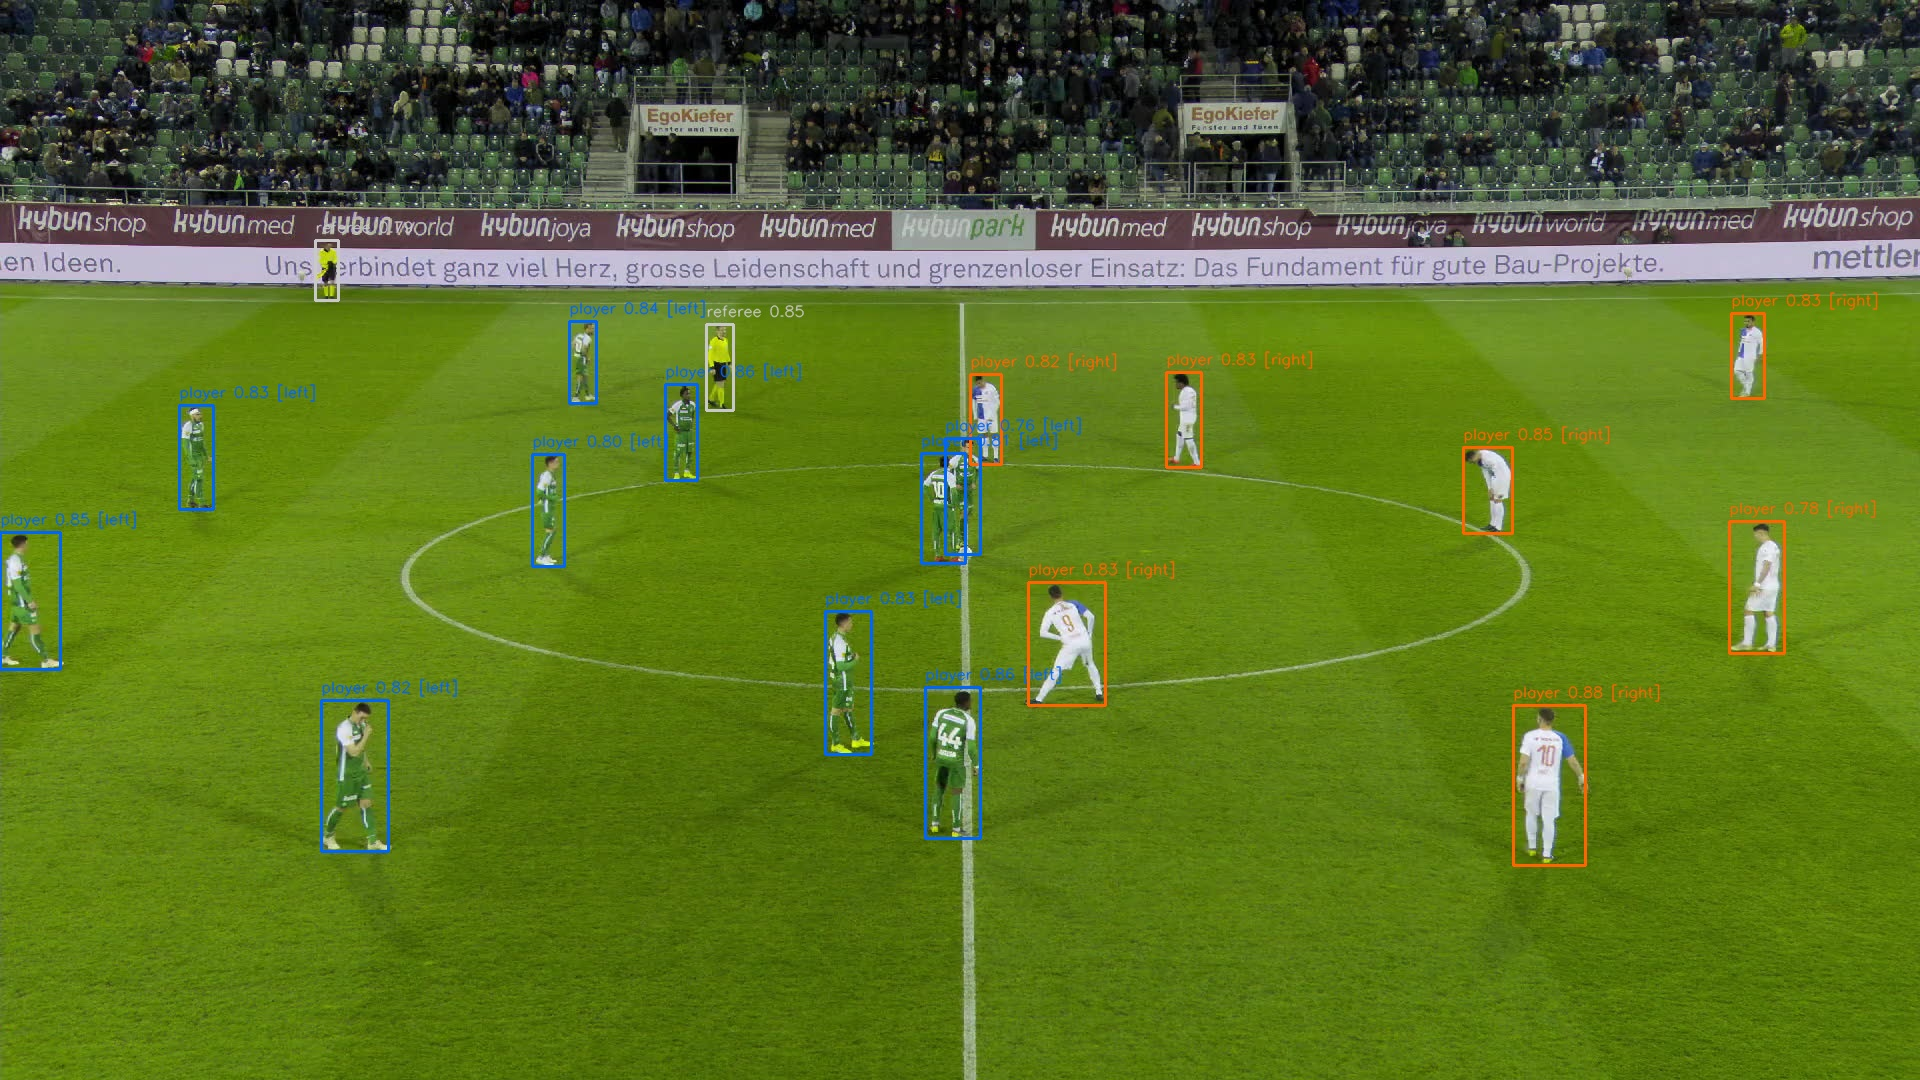

In [4]:
from IPython.display import Image, display

display(Image(filename=str(image_path)))


## Folder image inference

Use this when your input is a directory of frames/images instead of a video.

In [6]:
folder = PROJECT_ROOT / "data" / "raw" / "tracking" / "train" / "SNMOT-060" / "img1"
output_video = output_dir / "SNMOT-060_team_classifier.mp4"
output_json = output_dir / "SNMOT-060_team_classifier.json"

folder_summary = clf.predict_folder(
    folder,
    output_video_path=output_video,
    output_json_path=output_json,
    output_fps=25.0,
    progress=True,
)
folder_summary


Processed 25 images (430 detections)
Processed 50 images (838 detections)
Processed 75 images (1235 detections)
Processed 100 images (1632 detections)
Processed 125 images (1995 detections)
Processed 150 images (2346 detections)
Processed 175 images (2714 detections)
Processed 200 images (3089 detections)
Processed 225 images (3465 detections)
Processed 250 images (3867 detections)
Processed 275 images (4323 detections)
Processed 300 images (4797 detections)
Processed 325 images (5316 detections)
Processed 350 images (5807 detections)
Processed 375 images (6304 detections)
Processed 400 images (6839 detections)
Processed 425 images (7391 detections)
Processed 450 images (7947 detections)
Processed 475 images (8472 detections)
Processed 500 images (8864 detections)
Processed 525 images (9222 detections)
Processed 550 images (9564 detections)
Processed 575 images (9890 detections)
Processed 600 images (10200 detections)
Processed 625 images (10565 detections)
Processed 650 images (10971 

{'folder_path': 'C:\\Users\\CPU13374\\Downloads\\SoccerNet\\data\\raw\\tracking\\train\\SNMOT-060\\img1',
 'output_video_path': 'C:\\Users\\CPU13374\\Downloads\\SoccerNet\\outputs\\detect_player\\infer\\team_classifier\\SNMOT-060_team_classifier.mp4',
 'output_json_path': 'C:\\Users\\CPU13374\\Downloads\\SoccerNet\\outputs\\detect_player\\infer\\team_classifier\\SNMOT-060_team_classifier.json',
 'images_found': 750,
 'images_processed': 750,
 'detections': 12983,
 'image_extensions': ['.jpg', '.jpeg', '.png', '.bmp', '.webp'],
 'output_fps': 25.0}

## Video inference

Set `video_path` to any local video. Use `max_frames` while testing if you do not want to process the full video.

In [ ]:
# Video input is intentionally out of scope now.
# Use clf.predict_folder(...) for image-folder-to-mp4 inference.
